# QTrans—SECOM 严格平衡二分类正式实验

本 Notebook 复现论文初稿的评价风格：严格 1:1 二分类、验证损失选择检查点、Accuracy 为主指标、Macro-F1 为关键辅助指标，并将四个微型模型的可训练参数差限制在 1% 内。

SECOM 原数据高度不平衡（1463:104）。固定抽取全部 104 个少数类和 104 个多数类，然后进行 5 折外层测试。每折的缺失值填充、ANOVA 特征选择和标准化只在该折训练部分拟合，不许使用验证或测试数据。

## 数据集公认性与边界

SECOM 是 UCI 的公开半导体制造基准数据集，已被明确用于超过 3 项可核查的同行评议研究，例如 [2018 年故障诊断实验评估](https://www.mdpi.com/2504-2289/2/4/30)、[2022 年 Applied Sciences 研究](https://www.mdpi.com/2076-3417/12/24/12917)、[2024 年预处理对比研究](https://pmc.ncbi.nlm.nih.gov/articles/PMC11398254/)、[2025 年 Journal of Computational Design and Engineering 研究](https://academic.oup.com/jcde/article/12/9/46/8232663)和 [2026 年子类发现研究](https://www.sciencedirect.com/science/article/pii/S0957417426002666)。官方数据说明见 [UCI SECOM](https://archive.ics.uci.edu/dataset/179/secom)。

本实验的「平衡 208 样本协议」是针对论文问题固定的派生协议，不是 UCI 官方榜单。结果只能与完全相同的平衡索引、外折和预处理协议比较。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch

from qcs_balanced_binary import (
    BINARY_SEEDS, BinaryExperimentConfig, audit_secom,
    experiment_progress, gradient_audit_binary, paired_comparisons,
    require_complete, run_secom_balanced,
)

pd.set_option('display.max_columns', 100)
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'qcs_balanced_binary.py').exists():
    raise RuntimeError('请从 /root/xxx/autodl 目录打开并运行本 Notebook')
DATA_DIR = PROJECT_DIR / 'data' / 'raw' / 'secom'
ARTIFACT_ROOT = PROJECT_DIR / 'artifacts' / 'balanced_binary_qtrans'
CONFIG = BinaryExperimentConfig()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(pd.DataFrame([{'data': str(DATA_DIR), 'artifacts': str(ARTIFACT_ROOT), 'device': str(DEVICE)}]))

/root/xxx/autodl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,data,artifacts,device
0,/root/xxx/autodl/data/raw/secom,/root/xxx/autodl/artifacts/balanced_binary_qtrans,cuda


## 1. 强制数据、切分、参数量和梯度审计

参数量审计不通过 1% 边界，或任一可训练参数没有有限梯度，程序会立即停止。

In [2]:
required = [DATA_DIR / 'secom.data', DATA_DIR / 'secom_labels.data']
for path in required:
    if not path.exists():
        raise FileNotFoundError(path)

audit = audit_secom(DATA_DIR, CONFIG)
display(pd.DataFrame([{
    key: value for key, value in audit.items()
    if key not in {'fold_distribution', 'parameter_audit'}
}]))
display(audit['fold_distribution'])
display(audit['parameter_audit'])
display(gradient_audit_binary(40, CONFIG, DEVICE))

,raw_samples,raw_features,raw_class_counts,missing_values,balanced_samples
0,1567,590,"[1463, 104]",41951,208


,outer_fold,split,class_0,class_1,total
0,0,train,66,66,132
1,0,val,17,17,34
2,0,test,21,21,42
3,1,train,66,66,132
4,1,val,17,17,34
5,1,test,21,21,42
6,2,train,66,66,132
7,2,val,17,17,34
8,2,test,21,21,42
9,3,train,66,67,133


,model,parameters,relative_to_quantum
0,quantum_transformer,7090,0.000000
1,tiny_transformer,7146,0.007898
2,mlp_mixer,7061,-0.004090
3,cnn_token_mixer,7082,-0.001128


,model,logit_shape,loss,missing_gradients,all_gradients_finite
0,quantum_transformer,"(2, 2)",0.975716,0,True
1,tiny_transformer,"(2, 2)",0.787275,0,True
2,mlp_mixer,"(2, 2)",0.681454,0,True
3,cnn_token_mixer,"(2, 2)",0.755518,0,True


## 2. 查看断点状态

正式实验为 `4 模型 × 5 训练种子 × 5 外折 = 100` 个训练任务。一个外折保存一次，可断点续跑。

In [3]:
progress_before = experiment_progress(ARTIFACT_ROOT, 'secom', BINARY_SEEDS)
display(progress_before.groupby('model')['complete'].agg(['sum', 'count']))
print(f"已完成 {int(progress_before['complete'].sum())}/{len(progress_before)} 个任务")

,sum,count
model,,
cnn_token_mixer,10,25
mlp_mixer,10,25
quantum_transformer,14,25
tiny_transformer,10,25


已完成 44/100 个任务


## 3. 运行全部正式训练

`MAX_JOBS=None` 表示跑完所有剩余任务。首次可暂改为 `1` 确认服务器环境，随后恢复 `None`。不要根据测试成绩更改模型、种子或预处理。

In [4]:
MAX_JOBS = None

secom_oof, secom_folds = run_secom_balanced(
    data_dir=DATA_DIR,
    artifact_dir=ARTIFACT_ROOT,
    seeds=BINARY_SEEDS,
    config=CONFIG,
    balance_seed=2026,
    split_seed=4096,
    max_jobs=MAX_JOBS,
    resume=True,
    device=DEVICE,
)
print(f'当前收集 {len(secom_folds)}/100 个折级结果')
print(f'当前形成 {len(secom_oof)}/20 个种子级 OOF 结果')
display(secom_oof)


[SECOM] model=quantum_transformer, seed=62, fold=5/5, device=cuda

[SECOM] model=tiny_transformer, seed=62, fold=1/5, device=cuda

[SECOM] model=tiny_transformer, seed=62, fold=2/5, device=cuda

[SECOM] model=tiny_transformer, seed=62, fold=3/5, device=cuda

[SECOM] model=tiny_transformer, seed=62, fold=4/5, device=cuda

[SECOM] model=tiny_transformer, seed=62, fold=5/5, device=cuda

[SECOM] model=mlp_mixer, seed=62, fold=1/5, device=cuda

[SECOM] model=mlp_mixer, seed=62, fold=2/5, device=cuda

[SECOM] model=mlp_mixer, seed=62, fold=3/5, device=cuda

[SECOM] model=mlp_mixer, seed=62, fold=4/5, device=cuda

[SECOM] model=mlp_mixer, seed=62, fold=5/5, device=cuda

[SECOM] model=cnn_token_mixer, seed=62, fold=1/5, device=cuda

[SECOM] model=cnn_token_mixer, seed=62, fold=2/5, device=cuda

[SECOM] model=cnn_token_mixer, seed=62, fold=3/5, device=cuda

[SECOM] model=cnn_token_mixer, seed=62, fold=4/5, device=cuda

[SECOM] model=cnn_token_mixer, seed=62, fold=5/5, device=cuda

[SECOM] mode

,dataset,model,seed,outer_folds,parameters,train_seconds,best_epoch,test_samples,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,secom,cnn_token_mixer,42,5,7082,4.608311,9.8,208,0.591346,0.591346,0.591558,0.591346,0.591110
1,secom,mlp_mixer,42,5,7061,5.696894,14.0,208,0.576923,0.576923,0.577961,0.576923,0.575510
2,secom,quantum_transformer,42,5,7090,73.997171,8.6,208,0.620192,0.620192,0.622746,0.620192,0.618207
3,secom,tiny_transformer,42,5,7146,7.018160,15.8,208,0.644231,0.644231,0.646177,0.644231,0.643043
4,secom,cnn_token_mixer,52,5,7082,5.438908,17.0,208,0.596154,0.596154,0.601562,0.596154,0.590705
5,secom,mlp_mixer,52,5,7061,7.586120,31.2,208,0.605769,0.605769,0.606399,0.605769,0.605185
6,secom,quantum_transformer,52,5,7090,80.193659,11.0,208,0.548077,0.548077,0.551282,0.548077,0.540904
7,secom,tiny_transformer,52,5,7146,9.038668,25.8,208,0.634615,0.634615,0.635417,0.634615,0.634074
8,secom,cnn_token_mixer,62,5,7082,2.848581,15.0,208,0.572115,0.572115,0.574605,0.572115,0.568515
9,secom,mlp_mixer,62,5,7061,3.918924,26.4,208,0.586538,0.586538,0.587054,0.586538,0.585926


## 4. 完整性门禁与论文结果

100/100 个任务完成前，下方单元会拒绝产生正式比较。五折测试预测会先拼成覆盖 208 个样本恰好一次的 OOF 结果，然后以 5 个训练种子作为重复实验单位；不将 5 折伪装成 5 个独立实验。

In [5]:
progress_after = experiment_progress(ARTIFACT_ROOT, 'secom', BINARY_SEEDS)
require_complete(progress_after)
RESULT_DIR = ARTIFACT_ROOT / 'secom'
oof = pd.read_csv(RESULT_DIR / 'oof_results.csv')
summary = pd.read_csv(RESULT_DIR / 'summary.csv')
display(summary)

paired_acc = paired_comparisons(oof, metric='accuracy')
paired_f1 = paired_comparisons(oof, metric='macro_f1')
paired_acc.to_csv(RESULT_DIR / 'paired_accuracy.csv', index=False)
paired_f1.to_csv(RESULT_DIR / 'paired_macro_f1.csv', index=False)
display(paired_acc)
display(paired_f1)

,model,seeds,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,balanced_acc_mean,parameters,train_seconds_mean
0,tiny_transformer,5,0.634615,0.014017,0.633427,0.015102,0.634615,7146,5.647882
1,cnn_token_mixer,5,0.598077,0.018496,0.595254,0.019265,0.598077,7082,3.800131
2,quantum_transformer,5,0.595192,0.029323,0.592426,0.031563,0.595192,7090,75.195230
3,mlp_mixer,5,0.594231,0.013851,0.593435,0.014251,0.594231,7061,4.702982


,reference,baseline,metric,paired_seeds,mean_difference,ci95_low,ci95_high,win_rate,paired_t_pvalue
0,quantum_transformer,tiny_transformer,accuracy,5,-0.039423,-0.081507,0.002661,0.2,0.059992
1,quantum_transformer,mlp_mixer,accuracy,5,0.000962,-0.044775,0.046698,0.6,0.956253
2,quantum_transformer,cnn_token_mixer,accuracy,5,-0.002885,-0.039828,0.034059,0.6,0.838981


,reference,baseline,metric,paired_seeds,mean_difference,ci95_low,ci95_high,win_rate,paired_t_pvalue
0,quantum_transformer,tiny_transformer,macro_f1,5,-0.041001,-0.087226,0.005224,0.2,0.069492
1,quantum_transformer,mlp_mixer,macro_f1,5,-0.001009,-0.049563,0.047546,0.6,0.956775
2,quantum_transformer,cnn_token_mixer,macro_f1,5,-0.002828,-0.041524,0.035869,0.6,0.849119


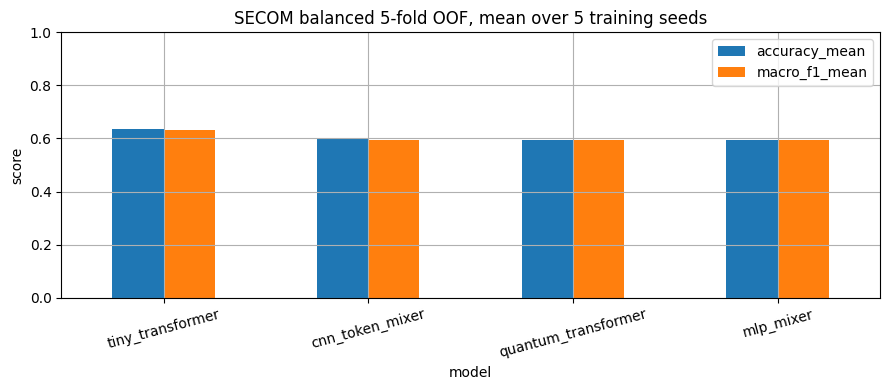

In [6]:
ax = summary.set_index('model')[['accuracy_mean', 'macro_f1_mean']].plot.bar(
    figsize=(9, 4), ylim=(0, 1), rot=15, grid=True
)
ax.set_ylabel('score')
ax.set_title('SECOM balanced 5-fold OOF, mean over 5 training seeds')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'formal_accuracy_macro_f1.png', dpi=300, bbox_inches='tight')
plt.show()

## 发表解读规则

只有当 QTrans 的 5 种子 Accuracy 和 Macro-F1 均值均领先，配对差值置信区间也支持方向一致时，才能写「在此固定微型模型协议下领先」。不能只挑一个种子，也不能扩大为对 SECOM 全部文献的 SOTA 声明。